## Load Data
We use the classic Iris dataset, loaded directly via scikit-learn's built-in loader for convenience. It contains 150 samples of iris flowers with 4 features (sepal/petal length and width) and a target label for 3 species.

In [1]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris(as_frame=True)
df = iris.frame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Train/Test Split
We split the data into 80% training and 20% test sets using a fixed random seed for reproducibility. This lets us evaluate the model on unseen data.

In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
X_train.shape, X_test.shape

((120, 4), (30, 4))

## Pipeline & Training
We build a scikit-learn Pipeline combining feature scaling (StandardScaler) with a Logistic Regression classifier. Using a Pipeline keeps preprocessing and modeling steps together and avoids data leakage. Training time is measured for reporting purposes.

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import time

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression())
])

start = time.time()
pipeline.fit(X_train, y_train)
train_time = time.time() - start
print(f"Training time: {train_time:.4f} seconds")

Training time: 0.0248 seconds


## Evaluation
We use the trained pipeline to predict labels on the test set and measure both prediction time and accuracy.

In [5]:
from sklearn.metrics import accuracy_score

start = time.time()
y_pred = pipeline.predict(X_test)
test_time = time.time() - start

accuracy = accuracy_score(y_test, y_pred)
print(f"Testing time: {test_time:.4f} seconds")
print(f"Accuracy: {accuracy:.4f}")

Testing time: 0.0076 seconds
Accuracy: 1.0000


## Visualization
A scatterplot of sepal length vs. sepal width, colored by species, gives a quick visual sense of how separable the classes are (similar to the plots on the Iris Wikipedia page).

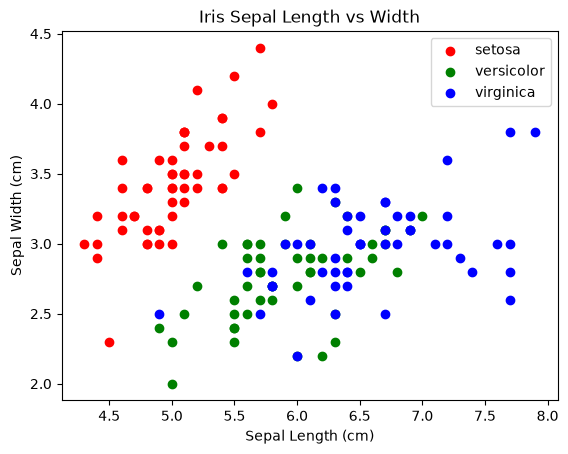

In [6]:
import matplotlib.pyplot as plt

species_names = iris.target_names  # ['setosa' 'versicolor' 'virginica']
colors = ['red', 'green', 'blue']

for i, species in enumerate(species_names):
    subset = df[df['target'] == i]
    plt.scatter(subset['sepal length (cm)'], subset['sepal width (cm)'],
                label=species, color=colors[i])

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Iris Sepal Length vs Width')
plt.legend()
plt.show()